# QuPer-SGI 데모: N=8, 패턴 k=6 (induced)

이 노트북은 QuPer 변분 양자 회로로 **부분그래프 동형(SGI)** 인스턴스를 푸는 전 과정을
단계별로 재현한다 (`runs/results/sgi8_p6_induced_*` 실험과 동일 설정).

- **문제**: 패턴 H(k=6 정점)가 타깃 그래프 B(N=8 정점)의 **induced** 부분그래프로
  임베딩되는 위치 찾기 (induced = 패턴의 엣지뿐 아니라 비엣지도 보존)
- **회로**: N=8 → q=log₂8=3, 보조 쌍 m=1 → 총 큐빗 **(q+m)×2 = (3+1)×2 = 8**
- **파이프라인**: 인스턴스 생성 → 회로(P̂ 생성) → 마스크 손실 → Adam → 투영 → 검증/시각화

참고 문서: `docs/PIPELINE.md`, `journal/2026-06-11_semantic-review.md`,
논문 arXiv:2505.05981 (Quantum 게재).

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "runs":   # 노트북은 runs/ 안에 있으므로 저장소 루트로 이동
    os.chdir("..")
sys.path.insert(0, os.getcwd())

# runs.visualize / runs.common 은 import 시 Agg 백엔드를 설정하므로 먼저 import한 뒤
# 인라인 백엔드로 되돌린다 (PNG 저장형 함수들은 백엔드와 무관하게 동작).
import runs.visualize
import runs.common
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from IPython.display import Image, display

# ---- 실험 파라미터 (여기만 바꾸면 다른 크기/패턴도 재현 가능) ----
NUM_VERTICES = 8      # N = 2^q  ->  q = 3
PATTERN_SIZE = 6      # 패턴 정점 수 k
INDUCED      = True   # induced SGI (False면 monomorphism: 엣지 보존만 요구)
SEED         = 0
ANSATZ       = "bruhat"
ANCILLAS     = 1      # 보조 쌍 m  ->  총 큐빗 2q+2m = 8
STEPS        = 300

OUT = Path("runs/results/demo_sgi8_p6_induced")
OUT.mkdir(parents=True, exist_ok=True)
print("작업 디렉토리:", os.getcwd())

작업 디렉토리: /home/HW/QUPER_GI_Implementation


## 1. 인스턴스 생성 — planted SGI

`make_subgraph_instance`의 구성 (정답 존재가 보장되는 planted 방식):

1. **host** = ER 랜덤 그래프 (N=8, p=0.5). **패턴 H = host의 앞 k개 정점이 이루는 부분그래프** (좌상단 k×k 블록).
2. **B** = host 전체를 숨김 순열 P\*로 섞은 것 (B = P\*ᵀ·host·P\*). H는 원래 host의 일부였으므로 **B 안에 반드시 임베딩이 존재**한다.
3. **mask** = 채점표. induced이므로 패턴 블록 k×k 안의 모든 정점쌍(대각 제외)이 제약이다.
   monomorphism이라면 패턴의 엣지 자리만 제약이 된다.

`perm_source="bruhat"`: 숨김 순열을 m=0 회로의 span 안에서 뽑아 **안사츠가 도달 가능한 정답**임을 보장
(논문 Fig. 18 설정). 균등 랜덤 순열은 대부분 span 밖이라 휴리스틱이 정확히 못 푸는 경우가 많다.

In [2]:
from quper_gi.graph_data import make_subgraph_instance, verify_subgraph_instance

host, b_mat, p_star, perm, mask = make_subgraph_instance(
    num_vertices=NUM_VERTICES,
    pattern_size=PATTERN_SIZE,
    edge_prob=0.5,
    seed=SEED,
    perm_source="bruhat",
    induced=INDUCED,
)
verify_subgraph_instance(host, b_mat, p_star, mask)   # planted 해가 제약을 만족하는지 사전 확인

pattern = host[:PATTERN_SIZE, :PATTERN_SIZE]
print(f"패턴 엣지 수   : {int(pattern.sum()//2)}")
print(f"타깃 B 엣지 수 : {int(b_mat.sum()//2)}")
print(f"마스크 제약 수 : {int(mask.sum()//2)}  (induced={INDUCED})")
print(f"숨김 순열 perm : {perm}")

패턴 엣지 수   : 8
타깃 B 엣지 수 : 13
마스크 제약 수 : 15  (induced=True)
숨김 순열 perm : [3 1 2 0 6 4 7 5]


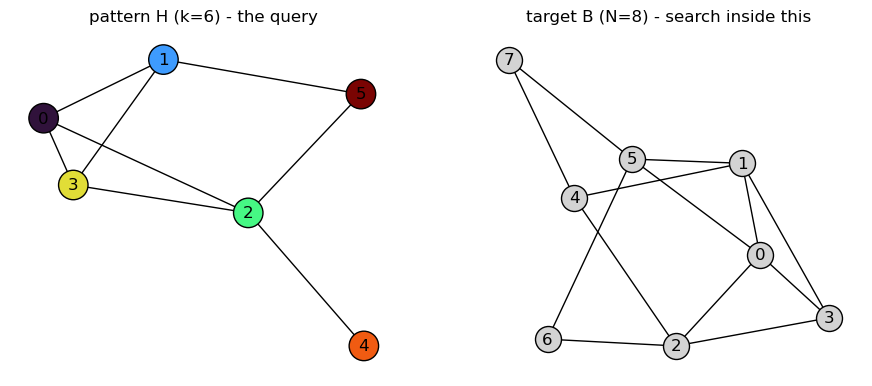

In [3]:
# 패턴 H와 타깃 B 시각화 (그림 내 텍스트는 폰트 문제로 영어)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
g_pat = nx.from_numpy_array(pattern)
g_b   = nx.from_numpy_array(b_mat)
cmap  = plt.get_cmap("turbo")
pat_colors = [cmap(i / max(1, PATTERN_SIZE - 1)) for i in range(PATTERN_SIZE)]

nx.draw_networkx(g_pat, nx.spring_layout(g_pat, seed=7), ax=axes[0],
                 node_color=pat_colors, edgecolors="black", node_size=450)
axes[0].set_title(f"pattern H (k={PATTERN_SIZE}) - the query")
axes[0].set_axis_off()

nx.draw_networkx(g_b, nx.spring_layout(g_b, seed=7), ax=axes[1],
                 node_color="lightgray", edgecolors="black", node_size=350)
axes[1].set_title(f"target B (N={NUM_VERTICES}) - search inside this")
axes[1].set_axis_off()
plt.show()

## 2. 양자 회로 구성 — 와이어 배치와 안사츠

고정 와이어 규약 (논문 Fig. 8 / README §3):

```
anc_ref [0]      ── H ──●──            (Bell 쌍의 참조측)
row     [1..3]   ── H ──●──            (행 레지스터)
anc_u   [4]      ───────X── U(θ) ──    (Bell 쌍의 활성측: U가 작용)
col     [5..7]   ───────X── U(θ) ── 측정(row+col)
```

- **Bell 쌍**: (anc_ref↔anc_u), (row↔col)에 H+CNOT — 최대 얽힘 상태 준비
- **U(θ) = X·B·W·B** (Bruhat 안사츠)가 anc_u+col 4개 와이어에만 작용
  - X = RX 층, B(Borel) = param_cx(상삼각), W(Weyl) = param_swap(인접 교환)
  - param_cx(0)=I, param_cx(π)=CNOT — θ가 게이트 on/off의 연속 스위치
- **측정**: row+col 6개 와이어의 확률 2³ˣ²=64개 → **P̂ = N × probs.reshape(8,8)** (논문 Eq. 3)
- P̂은 항상 이중확률행렬(DSM)이고, θ∈{0,π}이면 정확한 순열행렬

파라미터 수: q_U = q+m = 4 → ℓ = q_U + 3·C(q_U,2) = 4 + 18 = **22개**

In [4]:
from quper_gi.dsm_circuit import QuPerDSM

model = QuPerDSM(num_vertices=NUM_VERTICES, ancillas=ANCILLAS, ansatz=ANSATZ)
print(model.summary())
print("anc_ref :", model.layout.anc_ref)
print("row     :", model.layout.row)
print("anc_u   :", model.layout.anc_u)
print("col     :", model.layout.col)
print("U(θ) 작용 와이어 :", model.layout.u_wires)
print("측정 와이어      :", model.layout.matrix_wires)
print("파라미터 수 ℓ    :", model.num_params)

QuPerDSM(N=8, q=3, m=1, qU=4, wires=8, ansatz=bruhat, params=22)
anc_ref : [0]
row     : [1, 2, 3]
anc_u   : [4]
col     : [5, 6, 7]
U(θ) 작용 와이어 : [4, 5, 6, 7]
측정 와이어      : [1, 2, 3, 5, 6, 7]
파라미터 수 ℓ    : 22


## 3. (side) 전체 회로 그리기 — 8큐빗 draw_mpl

N=8이면 q=3이므로 (3+1)×2 = **8큐빗** 시스템이다. 아래 그림에서 확인할 것:

- 맨 앞: Hadamard + CNOT 4쌍 (Bell 쌍 준비: 와이어 0↔4, 1↔5, 2↔6, 3↔7)
- 중간: 와이어 4~7에만 걸리는 RX 층 → Borel(PhaseShift+CRX) → Weyl(CNOT·CRX·CNOT 묶음) → Borel
- 끝: 와이어 1,2,3,5,6,7 (row+col) 확률 측정

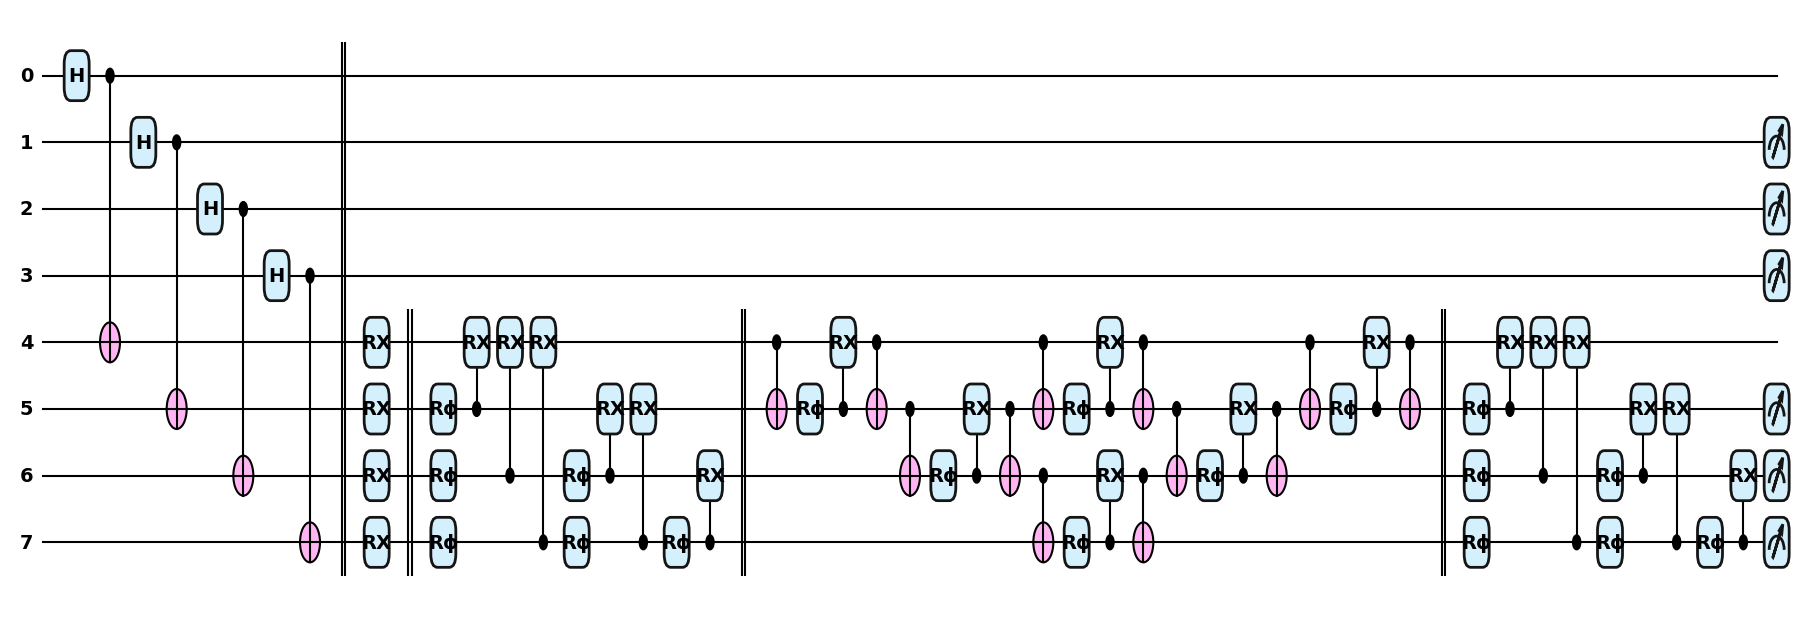

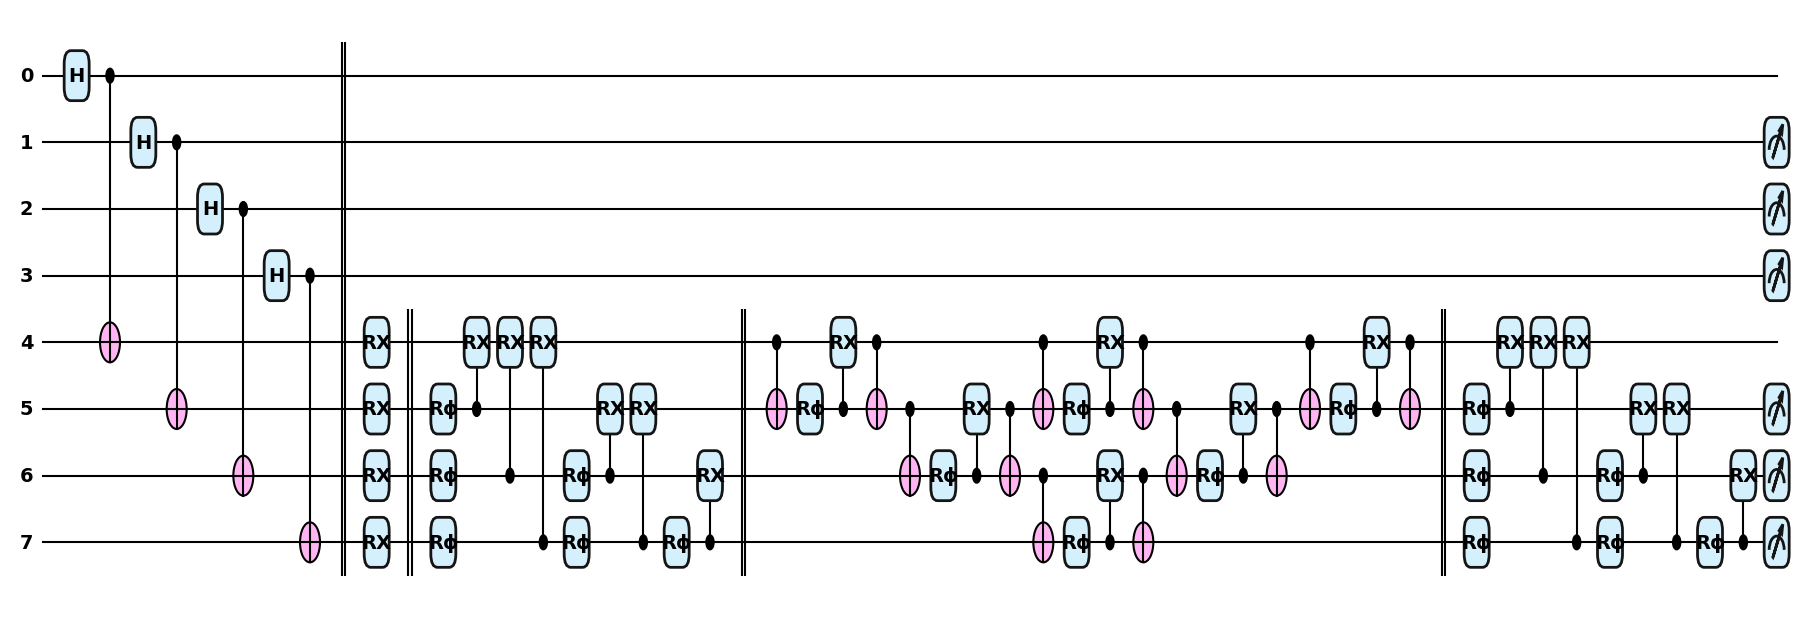

In [5]:
import pennylane as qml
from quper_gi.optimizer import initialize_theta

theta_demo = initialize_theta(model.num_params, seed=SEED)   # θ ~ U(π/2 ± 0.05), Algorithm 1

# 그리기 전용 모델: visual_barriers=True 가 기능 블록 사이에 구분선(Barrier)을 넣는다
# (only_visual — 상태/시뮬레이션에는 영향 없음). 구간: Bell쌍 | X층 | Borel | Weyl | Borel
model_draw = QuPerDSM(num_vertices=NUM_VERTICES, ancillas=ANCILLAS, ansatz=ANSATZ,
                      visual_barriers=True)
fig, ax = qml.draw_mpl(model_draw.qnode, decimals=None, style="pennylane")(theta_demo)
fig.set_size_inches(18, 6)
fig.savefig(OUT / "circuit.png", dpi=150, bbox_inches="tight")
fig

## 4. 손실 함수와 초기 P̂

학습 목적함수 (논문 §6.2의 ℓ_R을 SGI용 마스크로 일반화):

$$L(\theta) = \underbrace{\sum_{ij} M_{ij}\,\big(host_{ij} - (\hat P B \hat P^\top)_{ij}\big)^2}_{\text{본 손실 (마스크 Frobenius)}}\; +\; 0.1\,st + 0.15\,S_\varepsilon + 0.01\,ort$$

첫 항이 "패턴 제약이 맞는가"를 재는 본 손실이고, 뒤의 세 항은 논문 §6.2에 그대로 나오는
**정규화 항**이다 (가중치 0.1 / 0.15 / 0.01도 논문 값). 세 항의 공통 목적은 하나다 —
**"P̂아, 흐릿한 혼합 상태로 머물지 말고 진짜 순열행렬처럼 굴어라"**:

| 항 | 식 | 쉬운 설명 |
|---|---|---|
| `st` (stochastic) | $\sum_j(\sum_i \hat P_{ij}-1)^2$ | **예산 검사.** 각 행/열은 배정 확률의 합이 정확히 1이어야 한다 (한 정점은 한 슬롯에). 합이 흐트러지면 벌점. 정확 시뮬레이션에서는 P̂이 항상 DSM이라 사실상 0이지만, 안전장치로 둔다. |
| `S_ε` (entropy) | $-\sum_{ij} \hat P_{ij}\log(\hat P_{ij}+\varepsilon)$ | **우유부단 벌점.** 칸 값이 0.3, 0.4처럼 어중간하게 퍼져 있으면(= "이 정점을 어디 보낼지 못 정함") 벌점이 크고, 0이나 1로 확실해질수록 작아진다. 안개 낀 DSM을 또렷한 순열 쪽으로 민다. |
| `ort` (orthogonality) | $\sum_{ij}(\hat P^\top\hat P - I)^2_{ij}$ | **겹치기 방지.** 순열행렬은 직교행렬($P^\top P=I$)이라는 성질을 이용 — 두 슬롯이 같은 정점을 반씩 나눠 갖는 식의 어중간한 배정에서 멀어지게 민다. |

논문의 표현으로는 *"각 항이 P̂을 순열로 강제하고, 손실 지형을 부드럽게 하는 데 도움을 준다"*.
즉 정답(순열)은 어차피 투영이 만들지만, 이 항들이 soft 학습 단계에서부터 P̂을 순열
근처로 유도해 투영이 정답을 낚기 쉽게 만든다.

- mask M이 0인 칸(패턴 블록 밖 = 더미 정점 자리)은 **본 손실의 gradient에 전혀 안 들어간다**
  (정규화 항들은 P̂ 전체에 작용)
- **투영은 미분 경로 밖**: 매 스텝 P̂을 Hungarian + random-order 50회로 순열화하고,
  마스크 손실로 채점해 best를 추적한다

초기 θ(π/2 근처)에서 P̂은 흐릿한 DSM이다 — 행·열 합이 1인지 먼저 확인한다.

P̂ 행합: [1. 1. 1. 1. 1. 1. 1. 1.]
P̂ 열합: [1. 1. 1. 1. 1. 1. 1. 1.]
초기 마스크 손실: 7.901908798396302


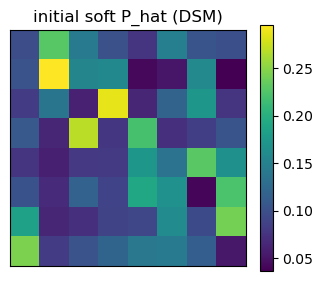

In [6]:
from quper_gi.losses import masked_frobenius_loss

p0 = np.asarray(model(theta_demo))
print("P̂ 행합:", np.round(p0.sum(axis=1), 6))
print("P̂ 열합:", np.round(p0.sum(axis=0), 6))
print("초기 마스크 손실:", float(masked_frobenius_loss(p0, host, b_mat, mask)))

plt.figure(figsize=(3.8, 3.2))
plt.imshow(p0, cmap="viridis"); plt.colorbar()
plt.title("initial soft P_hat (DSM)")
plt.xticks([]); plt.yticks([]); plt.show()

## 5. 학습 — Adam + 매 스텝 투영

`GIConfig` 기본값은 전부 논문값이다: Adam lr 0.4 (§6.3), 정규화 0.1/0.15/0.01 (§6.2),
매 스텝 투영 + random-order 50회 (Algorithm 1, App. C).
`train_single_m(mask=...)`이 마스크 손실로 학습하고, 투영 후보도 마스크 손실로 채점한다.
history에는 FOM 계측(grad_norm, P̂ 엔트로피, 투영잔차, 방문 순열 수)이 자동 기록된다.

투영 손실이 0에 도달하면(= 모든 제약 만족) 조기 종료한다.

In [7]:
from quper_gi.configs import GIConfig
from quper_gi.optimizer import train_single_m

cfg = GIConfig(num_vertices=NUM_VERTICES, ancillas=ANCILLAS, ansatz=ANSATZ,
               steps=STEPS, seed=SEED, perm_source="bruhat")

result = train_single_m(host, b_mat, p_star, cfg, mask=mask)
print(f"\nbest masked loss = {result['value']} (step {result['step']}, via {result['projection']})")

QuPerDSM(N=8, q=3, m=1, qU=4, wires=8, ansatz=bruhat, params=22)
step=00000 train=10.3189 proj=6 best=6 via=random_order_0


/home/HW/miniconda3/envs/quantum_env/lib/python3.11/site-packages/autograd/numpy/numpy_wrapper.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
  return A.astype(dtype, order, casting, subok, copy)


step=00010 train=5.96256 proj=4 best=4 via=random_order_27


step=00020 train=3.59613 proj=4 best=4 via=hungarian


step=00030 train=2.83364 proj=4 best=4 via=hungarian


...

step=00160 train=2.62062 proj=4 best=4 via=hungarian


step=00170 train=2.62062 proj=4 best=4 via=hungarian


step=00180 train=2.62063 proj=4 best=4 via=hungarian


step=00190 train=2.62065 proj=4 best=4 via=hungarian


Success: projected GI loss reached zero.

best masked loss = 0.0 (step 196, via random_order_48)


## 6. 검증 — 임베딩 판정과 매핑 σ

- **성공** = 마스크 제약 전부 만족 (induced이므로 "패턴 블록과 B 부분행렬이 정확히 일치")
- σ(i) = 패턴 정점 i가 임베딩된 B의 정점. **σ의 앞 k개만 의미가 있고**,
  나머지는 더미 정점의 자유 배정이다
- 주의: 실패해도 "임베딩이 없다"의 증명이 아니다 (휴리스틱, one-sided)

In [8]:
from quper_gi.metrics import is_sgi_success, subgraph_violations

p_best = result["p"]
sigma = np.argmax(p_best, axis=1)[:PATTERN_SIZE]
print("성공 여부 :", bool(is_sgi_success(host, b_mat, p_best, mask)))
print("위반 제약 :", subgraph_violations(host, b_mat, p_best, mask), "/", int(mask.sum()//2))
print("임베딩 매핑 (패턴 정점 i → B 정점 σ(i)):")
for i, s in enumerate(sigma):
    print(f"  h{i} → B{int(s)}")

성공 여부 : True
위반 제약 : 0 / 15
임베딩 매핑 (패턴 정점 i → B 정점 σ(i)):
  h0 → B0
  h1 → B1
  h2 → B2
  h3 → B3
  h4 → B6
  h5 → B4


## 7. 시각화 — heatmap / matching / FOM

**heatmap 읽는 법** (5패널):
1. 타깃 B 전체 — 빨간 행/열 = 순열이 골라낸 임베딩 위치
2. 그 행/열을 **그대로(오름차순)** 오려낸 부분행렬
3. 패턴 슬롯 순서로 **재배열한** 부분행렬 — 재배열이 곧 "찾은 대응"의 적용이다
4. 패턴 H
5. mask⊙|H − 재배열| — **전부 흰색이면 임베딩 성립**. induced이므로 3번과 4번은
   엣지 수까지 정확히 같아야 한다 (mono라면 3번이 여분 엣지를 더 가질 수 있음)

**matching** 그림: 왼쪽 패턴, 오른쪽 B — 같은 색 정점끼리 매칭, 위반 엣지는 빨간 점선.

[visualize] SGI heatmaps saved to: runs/results/demo_sgi8_p6_induced/heatmaps.png


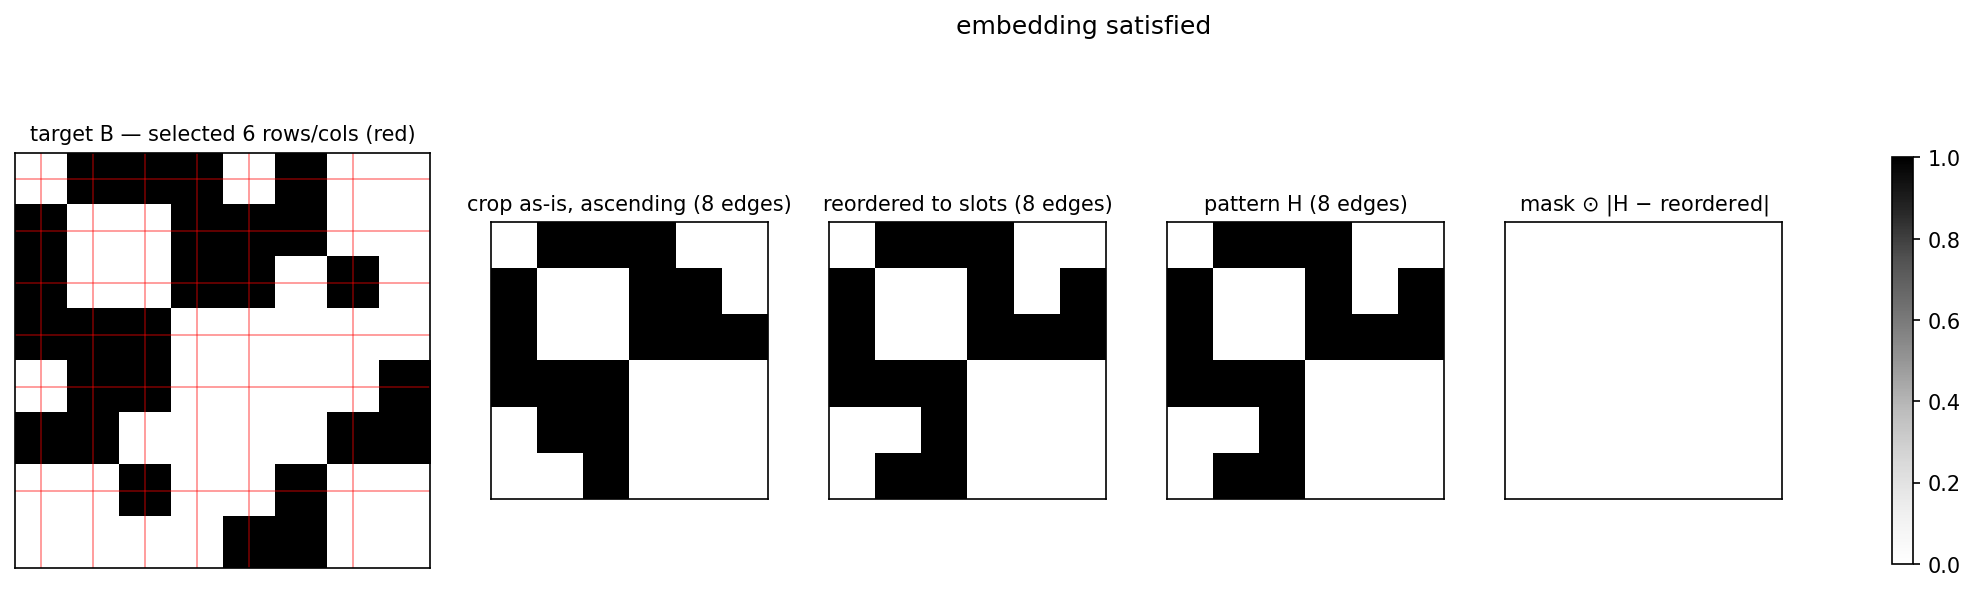

In [9]:
from runs.visualize import plot_sgi_heatmaps, plot_sgi_matching, plot_fom_panel
from runs.common import plot_loss_curve

plot_sgi_heatmaps(host, b_mat, p_best, mask, PATTERN_SIZE, OUT / "heatmaps.png")
Image(str(OUT / "heatmaps.png"))

[visualize] SGI matching plot saved to: runs/results/demo_sgi8_p6_induced/matching.png


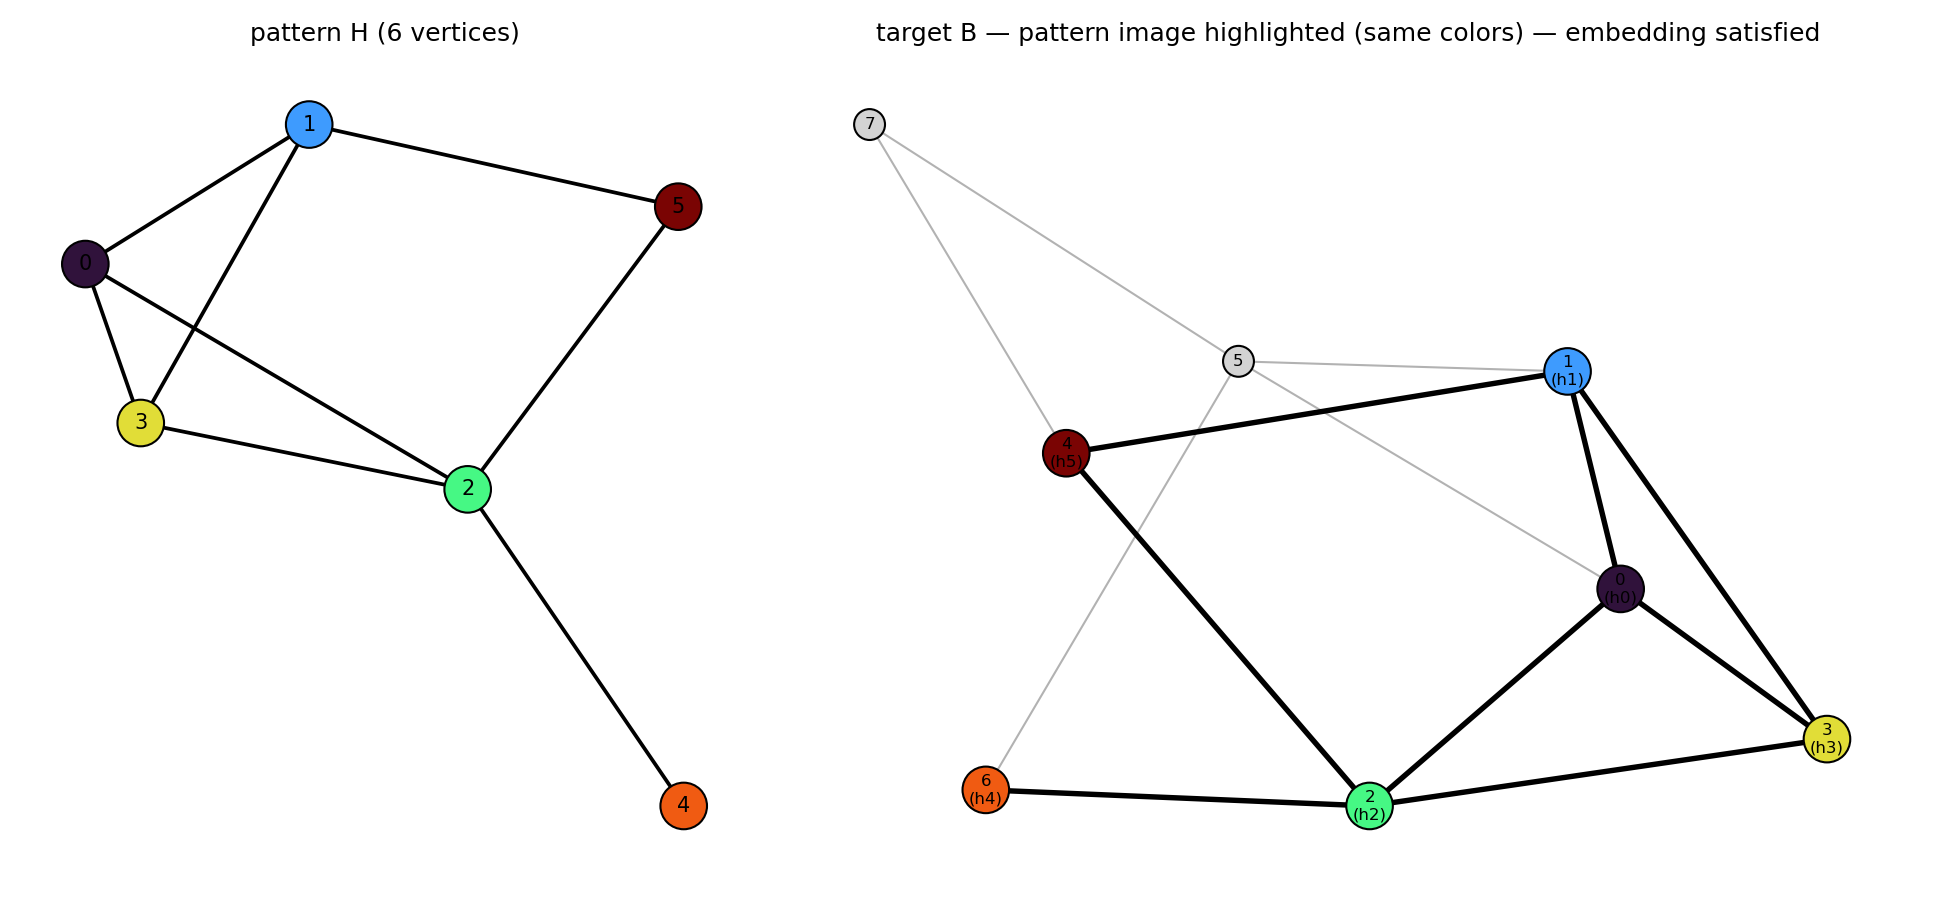

In [10]:
plot_sgi_matching(host, b_mat, p_best, mask, PATTERN_SIZE, OUT / "matching.png")
Image(str(OUT / "matching.png"))

[visualize] FOM panel saved to: runs/results/demo_sgi8_p6_induced/fom.png


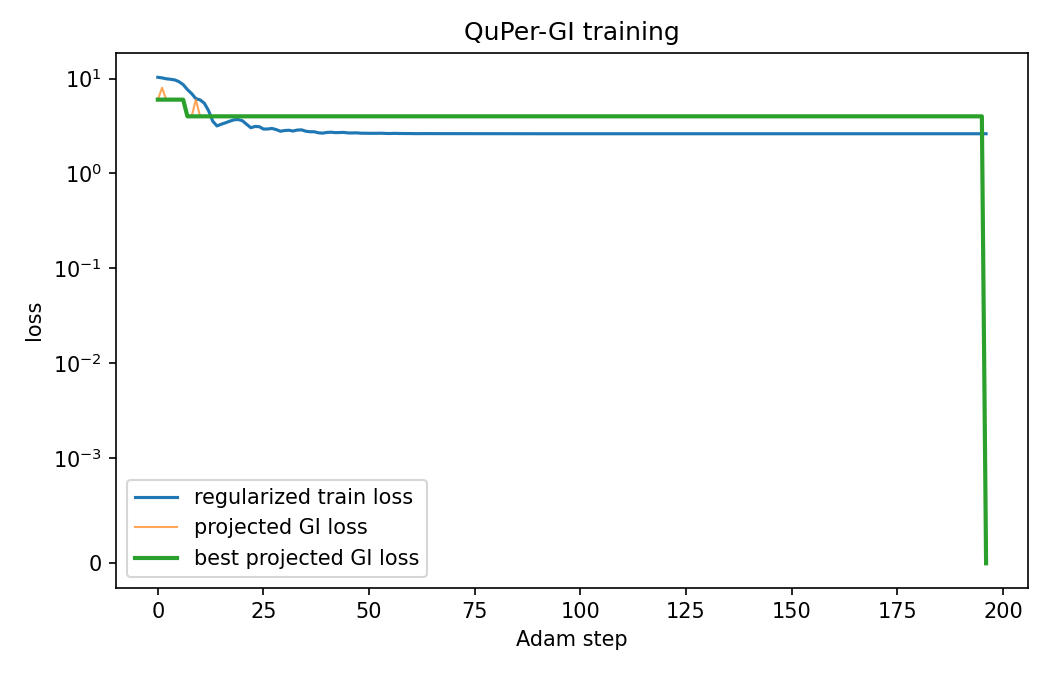

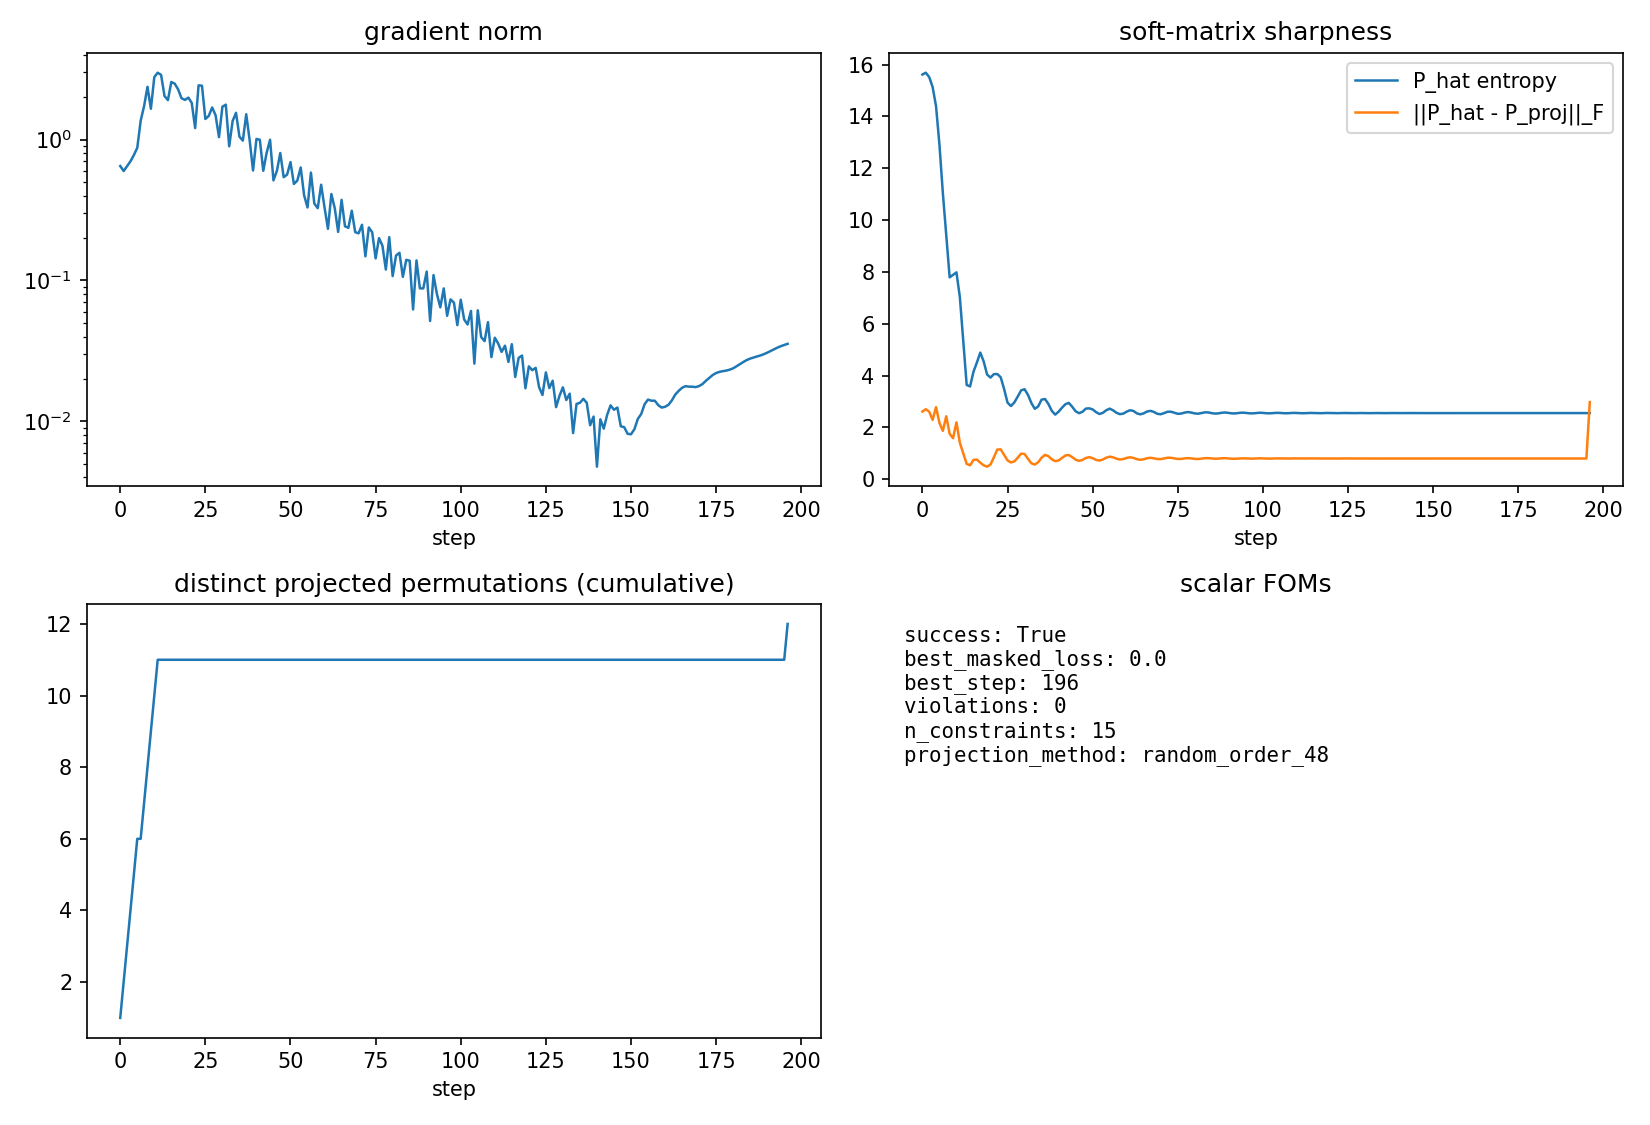

In [11]:
# 학습 곡선 + FOM 패널 (grad norm / sharpness / 방문 순열 수 / 스칼라 지표)
history = result["history"]
plot_loss_curve(history, OUT / "loss_curve.png")

fom = {
    "success": bool(is_sgi_success(host, b_mat, p_best, mask)),
    "best_masked_loss": result["value"],
    "best_step": result["step"],
    "violations": subgraph_violations(host, b_mat, p_best, mask),
    "n_constraints": int(mask.sum()//2),
    "projection_method": result["projection"],
}
plot_fom_panel(history, fom, OUT / "fom.png")
display(Image(str(OUT / "loss_curve.png")))
display(Image(str(OUT / "fom.png")))

## 8. 정리

- **푼 것**: "패턴 H(k=6)가 B(N=8)에 induced 임베딩되는 위치" — 전체 8×8 순열을 변분
  최적화하되 마스크된 패턴 제약만 채점하는 방식. 더미 정점 2개의 배정은 자유.
- **회로 자원**: 8큐빗, 파라미터 22개, 깊이 O(q) — 정점 수의 로그 스케일.
- **한계**: planted-yes 인스턴스의 탐색 능력만 본 것. 실패는 임베딩 부재의 증명이 아니며
  (one-sided), N=64부터는 단일 시도 성공률이 떨어진다 (multi-start 필요;
  `journal/2026-06-11_optimization-experiments.md` 참조).
- 같은 노트북에서 `INDUCED=False`(monomorphism), `NUM_VERTICES`/`PATTERN_SIZE` 변경으로
  다른 설정도 바로 재현할 수 있다.